# 01 — Data Inventory

A first look at the data after processing the raw datasets. The preprocessing step that includes
downloading, anonymising, fixing types, structural checks, etc already happened in
`src/rental_ranking/data/` (backed by 209 tests). Here we present the data we will works with and the findings we made while exploring it.

Four interesting facts that emerged after inspecting the datasets:

1. The snapshot's release date is **not** the date a listing was actually observed.
2. A few calendar and review rows point at listings that don't exist.
3. Eight listings carry slightly more than 365 days.
4. One column that ships with the data quietly encodes the prediction target.

## 0. The available data

The dataset comprises three markets, Athens, Crete and Thessaloniki. There is one snapshot for each, merged into one parquet file per entity (listings, calendar, reviews).

In [1]:
import pandas as pd

from rental_ranking import eda
from rental_ranking.data.download import SNAPSHOTS
from rental_ranking.data.paths import PROCESSED_DIR

pd.set_option("display.width", 120)

listings_df = pd.read_parquet(PROCESSED_DIR / "listings.parquet")
calendar_df = pd.read_parquet(PROCESSED_DIR / "calendar.parquet")
reviews_df = pd.read_parquet(PROCESSED_DIR / "reviews.parquet")

Bellow is a first look on how these datasets look like.

In [19]:
listings_df.head(2)

,id,name,host_id,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,...,reviews_per_month,host_is_local,host_has_about,license_status,license_hash,bathrooms_shared,user_tenure_months,host_tenure_months,city,scrape_date
0,88b161218e2a,Ellywood,42fc852b6394,False,1,True,True,Ampelokipon – Menemeni,40.649130,22.924160,...,0.48,local,False,registered,4808467ce882,False,140,14,thessaloniki,2026-06-29
1,a081fa9ed4cd,Studio in Mpotsari Str,5ba35f206944,False,5,True,True,Thessaloniki,40.607155,22.964315,...,NaN,unknown,False,registered,60446a3831b5,False,46,46,thessaloniki,2026-06-29
2,f9a55d38115c,"Arama, Nilie Hospitality MGMT",657206f5cc81,False,252,True,True,Thessaloniki,40.630750,22.947490,...,NaN,local,True,registered,8cf3f07d00ce,False,89,83,thessaloniki,2026-06-29
3,449c5398cf8b,MainAvenue Living Aristotelous,b14e58db5c87,False,5,True,True,Thessaloniki,40.634760,22.945080,...,1.11,unknown,False,registered,cefcca219864,False,51,50,thessaloniki,2026-06-29
4,3348da340093,Compact Room - Colors Central Ladadika,f632f6426b1a,False,4,True,True,Thessaloniki,40.634180,22.937130,...,NaN,unknown,False,registered,429dbd7d288e,False,4,4,thessaloniki,2026-06-29


In [20]:
calendar_df.head(2)

,listing_id,date,available
0,ad9b900e0955,2026-06-29,False
1,ad9b900e0955,2026-06-30,False
2,ad9b900e0955,2026-07-01,True
3,ad9b900e0955,2026-07-02,True
4,ad9b900e0955,2026-07-03,True


In [21]:
reviews_df.head(2)

,listing_id,id,date,comments
0,ad9b900e0955,1402784,2012-06-02,Stel's apartment was perfect for my needs! Qui...
1,ad9b900e0955,1699771,2012-07-13,"we have stayed in Stelios studio, very nice pl..."
2,ad9b900e0955,1877290,2012-08-03,"Stelios, thank you! We had the best holidays e..."
3,ad9b900e0955,2034335,2012-08-19,Apartment was perfect for us. Would highly rec...
4,ad9b900e0955,2133940,2012-08-29,"Stelios is a perfect host, helpful and friendl..."


The available data in numbers:

In [3]:
# Orphan listing_ids map to NaN and drop out of value_counts
city_of = listings_df.set_index("id")["city"]

row_counts = pd.DataFrame(
    {
        "listings": listings_df.groupby("city").size(),
        "calendar": calendar_df["listing_id"].map(city_of).value_counts(),
        "reviews": reviews_df["listing_id"].map(city_of).value_counts(),
    }
)
row_counts.loc["total"] = row_counts.sum()
row_counts

,listings,calendar,reviews
athens,14337,5233007,917783
crete,27333,9976554,612719
thessaloniki,4965,1812225,235114
total,46635,17021786,1765616


## 1. When was it observed?

There are three date definitions in play here, and it's easy to assume they are the same thing. So lets carefully define them:

| date | meaning | granularity | origin |
| --- | --- | --- | --- |
| `release_date` | when Inside Airbnb *published* the snapshot | per city | Inside Airbnb website |
| `scrape_date` | when *this listing* was observed (`last_scraped`) | per listing | listings |
| `T` | this listing's first calendar day, the label anchor | per listing | calendar |

`T` (for Time threshold) is each listing's own first calendar day, computed as `min(calendar.date)`. It's a per-listing date, not
a per-city one, and we use it throughout this project as an anchor date in order to derive how many of the next 90 days are available for booking for each listing.

In [22]:
day_start = calendar_df.groupby("listing_id")["date"].transform("min")
window_90 = calendar_df[calendar_df["date"] < day_start + pd.Timedelta(days=90)]

by_listing = calendar_df.groupby("listing_id")["date"]
calendar_facts = pd.DataFrame(
    {
        "T": by_listing.min(),
        "calendar_days": by_listing.size(),
        "calendar_span": (by_listing.max() - by_listing.min()).dt.days + 1,
        "avail_90": window_90.groupby("listing_id")["available"].sum(),
    }
)
calendar_facts["blocked_fraction_90"] = 1 - calendar_facts["avail_90"] / 90

# Every window must be a full 90 days, or the fraction above has a moving denominator.
assert window_90.groupby("listing_id").size().eq(90).all()

listings = listings_df.merge(calendar_facts, left_on="id", right_index=True, how="left")
listings["release_date"] = pd.to_datetime(listings["city"].map(lambda c: SNAPSHOTS[c]["as_of"]))
dates_by_city = listings.groupby("city")[["release_date", "scrape_date", "T"]].agg(["min", "max"])
dates_by_city

release_date            scrape_date                     T           
                      min        max         min        max        min        max
city                                                                             
athens         2026-06-28 2026-06-28  2026-06-28 2026-06-30 2026-06-28 2026-06-30
crete          2026-06-29 2026-06-29  2026-06-29 2026-07-03 2026-06-29 2026-07-03
thessaloniki   2026-06-29 2026-06-29  2026-06-29 2026-07-02 2026-06-29 2026-07-02

The above table shows how those three dates differ.

In [23]:
scraped_on_release = (
    listings.assign(on_release=listings["scrape_date"].eq(listings["release_date"]))
    .groupby("city")
    .agg(n_listings=("id", "size"), share_scraped_on_release_date=("on_release", "mean"))
)
scraped_on_release

,n_listings,share_scraped_on_release_date
city,,
athens,14337,0.033550
crete,27333,0.151538
thessaloniki,4965,0.940987


The important thing to note here: **the release date is not an observation date.** Only 3.4 % of Athens listings were actually
scraped on the day the snapshot folder is named after; Crete manages 15.2 %.

This is why T is anchored per listing and why no per-city date is hardcoded, as a single
fixed date for Crete would be wrong for roughly 85 % of that market.

In [24]:
listings["lag_days"] = (listings["T"] - listings["scrape_date"]).dt.days

anchor_agreement = listings.groupby("city").agg(
    n_listings=("id", "size"),
    T_missing=("T", lambda s: s.isna().sum()),
    share_T_eq_scrape=("lag_days", lambda s: s.eq(0).mean()),
    n_mismatched=("lag_days", lambda s: s.ne(0).sum()),
)
anchor_agreement

,n_listings,T_missing,share_T_eq_scrape,n_mismatched
city,,,,
athens,14337,0,0.999651,5
crete,27333,0,0.999232,21
thessaloniki,4965,0,1.000000,0


In [7]:
# The exceptions, made visible rather than hidden behind a 99.9 % headline.
listings.groupby("city")["lag_days"].value_counts().unstack(fill_value=0)

lag_days,-2,-1,0
city,,,
athens,0,5,14332
crete,13,8,27312
thessaloniki,0,0,4965


T and `scrape_date` agree for all but **26 listings**, and every disagreement runs the same
way: the calendar starts one or two days *before* the listing row was scraped. For those 26
listings, the attributes were recorded shortly after the label window had already opened.

That's a tiny 0.06 % of rows but it is a genuine ordering violation between features and the 
label we will build.

## 2. Joining the datasets

The three tables are linked by hashed listing IDs. `build.py` checks for mismatches at build
time; this section shows what it found.

In [8]:
known_ids = set(listings_df["id"])
calendar_orphans = sorted(set(calendar_df["listing_id"]) - known_ids)
reviews_orphans = sorted(set(reviews_df["listing_id"]) - known_ids)

pd.DataFrame(
    {
        "orphan_listing_ids": [len(calendar_orphans), len(reviews_orphans)],
        "affected_rows": [
            int(calendar_df["listing_id"].isin(calendar_orphans).sum()),
            int(reviews_df["listing_id"].isin(reviews_orphans).sum()),
        ],
    },
    index=["calendar", "reviews"],
)

,orphan_listing_ids,affected_rows
calendar,5,1825
reviews,1,2


In [9]:
# Every reviews orphan is also a calendar orphan: the same listings, missing from one file.
set(reviews_orphans) <= set(calendar_orphans)

True

Five listings appear in Athens' calendar (1,825 rows), and one of them also in
its reviews (2 rows), without a matching row in the listings table. Thessaloniki and Crete are
clean.

These "orphan" ids get dropped by the inner join at feature-building time. The exact orphan set is pinned in `tests/test_io.py` (as **raw**
ids, since the hashed ones change with the salt), so if a future snapshot introduces a *new*
orphan, a test fails instead of the row being silently absorbed.

## 3. Does the calendar behave?

Here we check two things:
- Does each listing carry a contiguous year of calendar starting at its own T?
- Does the calendar reproduce the `availability_90` column that Inside Airbnb ships?

In [10]:
irregular = calendar_facts[calendar_facts["calendar_days"].ne(365)]
print(f"listings without exactly 365 calendar days: {len(irregular)}")
print(
    f"all spans contiguous (days == span): {calendar_facts['calendar_days'].eq(calendar_facts['calendar_span']).all()}"
)

listings.loc[listings["id"].isin(irregular.index), ["city", "scrape_date", "T", "calendar_days"]]

listings without exactly 365 calendar days: 8
all spans contiguous (days == span): True


,city,scrape_date,T,calendar_days
15978,athens,2026-06-30,2026-06-29,366
15979,athens,2026-06-30,2026-06-29,366
20410,crete,2026-07-01,2026-06-30,366
31002,crete,2026-07-01,2026-06-30,366
31007,crete,2026-07-01,2026-06-30,366
31273,crete,2026-07-01,2026-06-29,367
44157,crete,2026-07-01,2026-06-29,367
44254,crete,2026-07-01,2026-06-29,367


Eight listings run 366–367 days instead of 365. Every calendar is *contiguous*, so these are
slightly longer. But there are no gaps, so the 90-day window is unaffected.

In [11]:
listings["avail_90_diff"] = listings["avail_90"] - listings["availability_90"]

listings.groupby("city").agg(
    exact_agreement=("avail_90_diff", lambda s: s.eq(0).mean()),
    n_mismatched=("avail_90_diff", lambda s: s.ne(0).sum()),
)

,exact_agreement,n_mismatched
city,,
athens,0.999861,2
crete,0.999744,7
thessaloniki,0.999597,2


The count of available days from the calendar reproduces the shipped `availability_90` for
**99.96–99.99 %** of listings. The tiny residual is due to scrape timing: Inside Airbnb computes
their column at the moment of the scrape, while our window is anchored on the calendar's own
first date.

That's independent enough to trust the calendar, and close enough to be confident the two are
measuring the same thing.

## 4. The leak

When scraping a listing's price, Inside Airbnb uses a scraper that walks forward in time until it finds a date that is bookable. The very first available check-in date is recorded in the `price_quote_checkin_date` column.
That's a direct read of the very availability our label will measure, sitting
inside what looks like harmless metadata.

Terms used below:

- **Blocked day**: a calendar row with `available = False`. **Not a booking**: hosts also
  block dates for personal use, maintenance and seasonal closure, and the data can't tell
  those apart from bookings. That's why the label is called a **demand proxy** throughout
  this project.
- **Blocked fraction (T→T+90)**: the proportion of a listing's first 90 days that are blocked.
  0.0 = fully available, 1.0 = nothing bookable.
- **Quote lead days**: `price_quote_checkin_date − T`. The number of days until the first bookable date. 0.0 = bookable immediately.

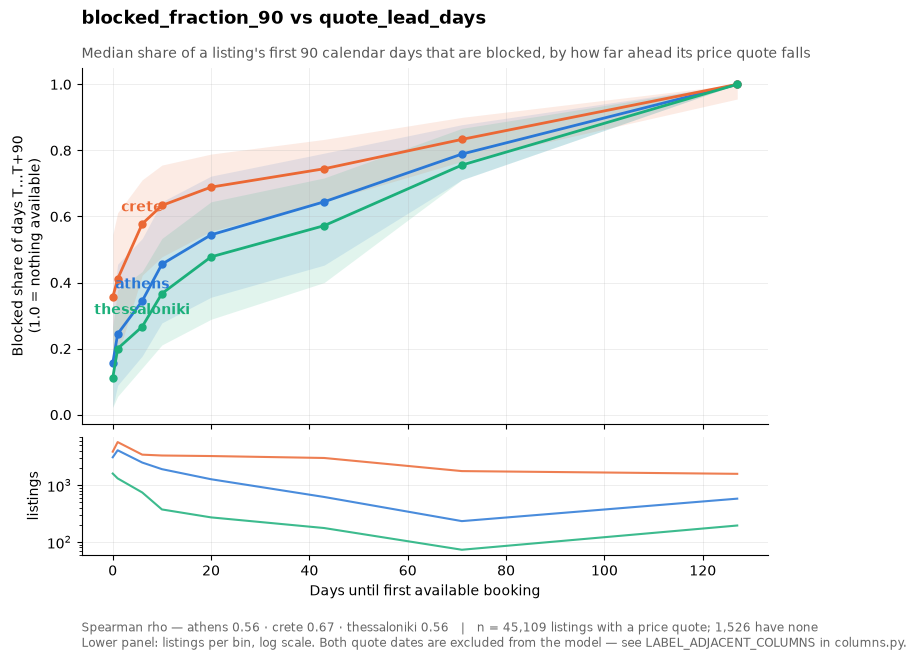

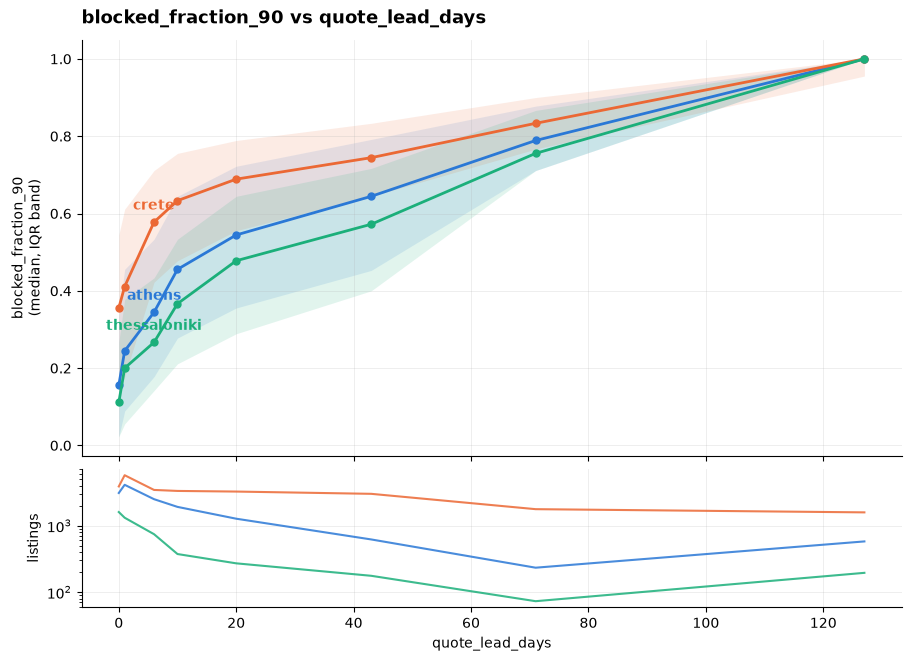

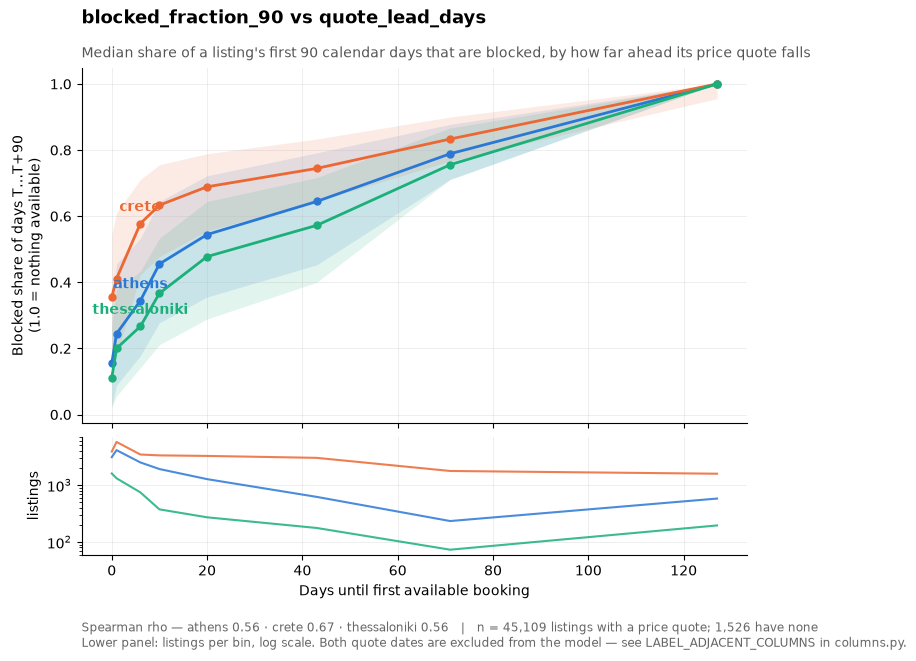

In [26]:
listings["quote_lead_days"] = (listings["price_quote_checkin_date"] - listings["T"]).dt.days

_, leak_stats = eda.plot_binned_relationship(
    listings["quote_lead_days"],
    listings["blocked_fraction_90"],
    group=listings["city"],
    bins=[-0.5, 0.5, 3, 7, 14, 30, 60, 90, 400],
)

caption = (
    "Spearman rho — "
    + " · ".join(f"{c} {s['spearman_rho']:.2f}" for c, s in leak_stats["groups"].items())
    + f"   |   n = {leak_stats['n_observations']:,} listings with a price quote; "
    + f"{listings['quote_lead_days'].isna().sum():,} have none"
    + "\nLower panel: listings per bin, log scale. Both quote dates are excluded from the"
    " model — see LABEL_ADJACENT_COLUMNS in columns.py."
)

fig, _ = eda.plot_binned_relationship(
    listings["quote_lead_days"],
    listings["blocked_fraction_90"],
    group=listings["city"],
    bins=[-0.5, 0.5, 3, 7, 14, 30, 60, 90, 400],
    # title="The price-quote date encodes the label it is meant to predict",
    subtitle=(
        "Median share of a listing's first 90 calendar days that are blocked, "
        "by how far ahead its price quote falls"
    ),
    xlabel=(
        "Days until first available booking"
    ),
    ylabel="Blocked share of days T…T+90\n(1.0 = nothing available)",
    caption=caption,
)
fig

Let's decrypt this graph: 
- The upper part shows how fraction of blocked days correlates with the number of days until the first available booking. This is an expected result, and a confirmation that including `price_quote_checkin_date` in the training data would leak the label.
- The lower part shows the number of listings against the number of days until the first available booking. Athens and Thessaloniki show a similar trend, while the Crete trend shows a straight line, reflecting the high demand for summer bookings in that island.

**Action taken:** `price_quote_checkin_date` and `price_quote_checkout_date` sit in
`LABEL_ADJACENT_COLUMNS` . These are columns that are kept in the processed table, but
blocked from ever reaching the model by `tests/test_columns.py`.

## 5. Two constraints for the labeling phase

During data exploration a couple of issues emerged related to the construction of the label.

The first one is related to the `price` column.
Below we check its missingness and distribution.

In [28]:
listings.groupby("city")["price"].agg(
    n_missing=lambda s: s.isna().sum(),
    pct_missing=lambda s: s.isna().mean(),
    median="median",
    quantile_90=lambda s: s.quantile(0.90),
)

,n_missing,pct_missing,median,quantile_90
city,,,,
athens,138,0.009625,105.0,230.004
crete,1815,0.066403,150.0,562.621
thessaloniki,247,0.049748,75.5,137.000


(<Figure size 1600x900 with 6 Axes>,
 {'n_valid': 44435,
  'n_missing': 2200,
  'n_total': 46635,
  'mean': 211.00328524811525,
  'median': 120.0,
  'mode': 80.0,
  'std': 418.8333445927849,
  'variance': 175421.3705427785,
  'range': 46265.73,
  'iqr': 123.0,
  'min': 2.77,
  'q1': 85.0,
  'q3': 208.0,
  'max': 46268.5,
  'skewness': 43.20438217445711,
  'kurtosis': 3822.6270110234514})

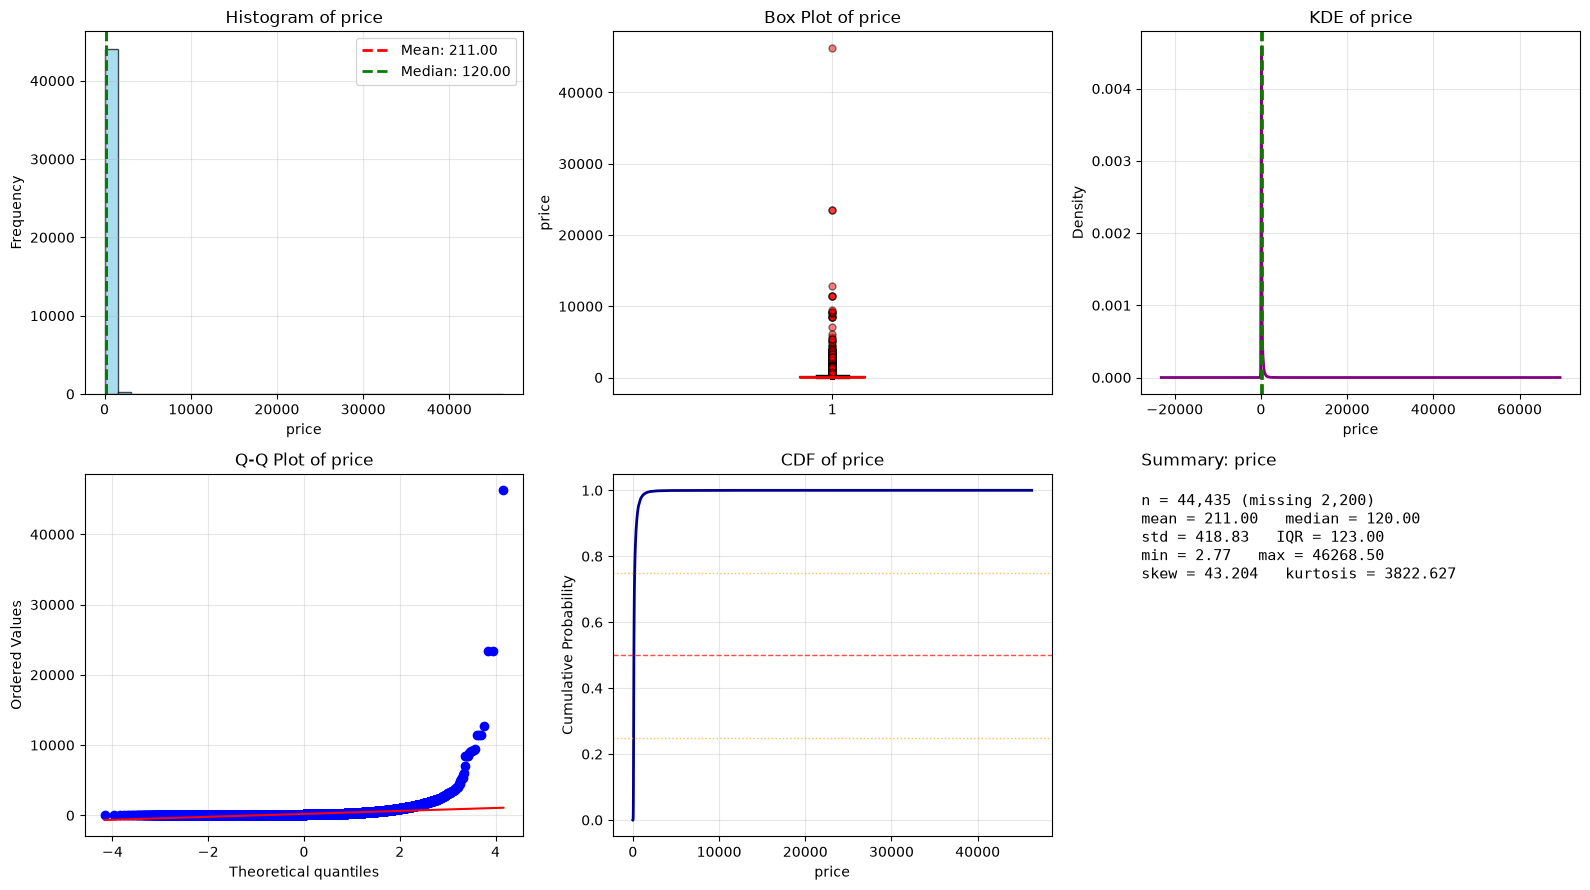

In [29]:
eda.analyze_numeric_variable(listings["price"])

As expected the majority of prices sit inside the 80-200 range, with a long tail at the right of the distribution, and a bunch of outlier values that call for carefull inspection. 
But the main issue arises from the very definition of `price` inside this dataset. Here, `price` is a **dated quote**, not a standing nightly rate. Ie, the Inside Airbnb scraper requests the next available booking date and it is handed back a price number which is used to populate the `price` column. If no nights are available for booking, then its value is missing. This means that price missingness tracks availability, which tracks the label. Price therefore has to be imputed
before any price tiers are built and before this feature gets fed to the model.

The imputation scheme is this: impute using the median price of each stratum defined by `(city, neighbourhood_cleansed, room_type, accommodates)`. The following table shows the benefits of binning the accommodates column into groups of 1–2, 3–4, 5–6, 8+, according their guest capacity.

In [34]:
STRATA_KEY = ["city", "neighbourhood_cleansed", "room_type", "accommodates"]

listings["capacity_tier"] = pd.cut(
    listings["accommodates"], [0, 2, 4, 7, 100], labels=["1-2", "3-4", "5-6", "8+"]
)
TIERED_KEY = ["city", "neighbourhood_cleansed", "room_type", "capacity_tier"]


def strata_profile(key: list[str]) -> dict:
    sizes = listings.groupby(key, observed=True).size()
    priced = listings.dropna(subset=["price"]).groupby(key, observed=True).size()
    unfillable = ~listings[listings["price"].isna()].set_index(key).index.isin(priced.index)
    return {
        "strata": len(sizes),
        "singletons": int(sizes.eq(1).sum()),
        "strata_with_at_least_10_listings": int(sizes.ge(10).sum()),
        "listings_in_strata_with_fewer_than_5_listings": int(sizes[sizes < 5].sum()),
        "price_nulls_with_no_median": int(unfillable.sum()),
    }


pd.DataFrame(
    {"raw accommodates": strata_profile(STRATA_KEY), "capacity tiers": strata_profile(TIERED_KEY)}
)

,raw accommodates,capacity tiers
strata,1140,525
singletons,244,74
strata_with_at_least_10_listings,484,296
listings_in_strata_with_fewer_than_5_listings,928,300
price_nulls_with_no_median,14,8


Without binning: **1,140 strata, 244 of them singletons** (a
stratum containing one listing), and 928 listings in strata of fewer than 5. Binning
`accommodates` into capacity tiers roughly halves the strata and cuts singletons to 74.

More importantly, **14 price-null rows have no non-null price anywhere in their own stratum**
, so imputing from the stratum median would just return NaN. Tiering reduces that to 8, not 0, so
a fallback cascade is needed either way: stratum → drop `accommodates` → drop `room_type` →
city median.

### What the query-group key produces

Next we validate the choice of capacity tiers grouping scheme and check how it fragments the data when the modeling phase arrives.
Again, the key the ranker will group
listings by is `city × neighbourhood_cleansed × room_type × capacity tier`. Groups holding a
single listing (or a single grade) contribute nothing to the ranking metric and waste the
model's training signal, so it's worth seeing what the other binning choices would play out down the road.

In [33]:
ranked = listings[
    ~(
        (listings["number_of_reviews"].eq(0) & listings["blocked_fraction_90"].eq(1.0))
        | (listings["minimum_nights"] > 30)
    )
].copy()
ranked["room_grp"] = ranked["room_type"].where(
    ranked["room_type"].isin(["Entire home/apt", "Private room"]), "Other"
)

CAPACITY_SCHEMES = {
    "raw accommodates": ranked["accommodates"],
    "1-2 / 3-4 / 5-6 / 7+": pd.cut(ranked["accommodates"], [0, 2, 4, 6, 100]),
    "1-2 / 3-4 / 5-7 / 8+": pd.cut(ranked["accommodates"], [0, 2, 4, 7, 100]),
    "1-2 / 3-4 / 5+": pd.cut(ranked["accommodates"], [0, 2, 4, 100]),
}


def group_profile(capacity: pd.Series) -> dict:
    sizes = (
        ranked.assign(cap=capacity)
        .groupby(["city", "neighbourhood_cleansed", "room_grp", "cap"], observed=True)
        .size()
    )
    return {
        "groups": len(sizes),
        "singletons": int(sizes.eq(1).sum()),
        "groups_with_fewer_than_5_listings": int(sizes.lt(5).sum()),
        "listings_in_groups_with_fewer_than_5_listings": int(sizes[sizes < 5].sum()),
        "median_group_size": int(sizes.median()),
    }


pd.DataFrame({name: group_profile(cap) for name, cap in CAPACITY_SCHEMES.items()})

,raw accommodates,1-2 / 3-4 / 5-6 / 7+,1-2 / 3-4 / 5-7 / 8+,1-2 / 3-4 / 5+
groups,1126,517,512,432
singletons,237,64,66,44
groups_with_fewer_than_5_listings,487,147,148,111
listings_in_groups_with_fewer_than_5_listings,911,282,284,216
median_group_size,6,15,15,18


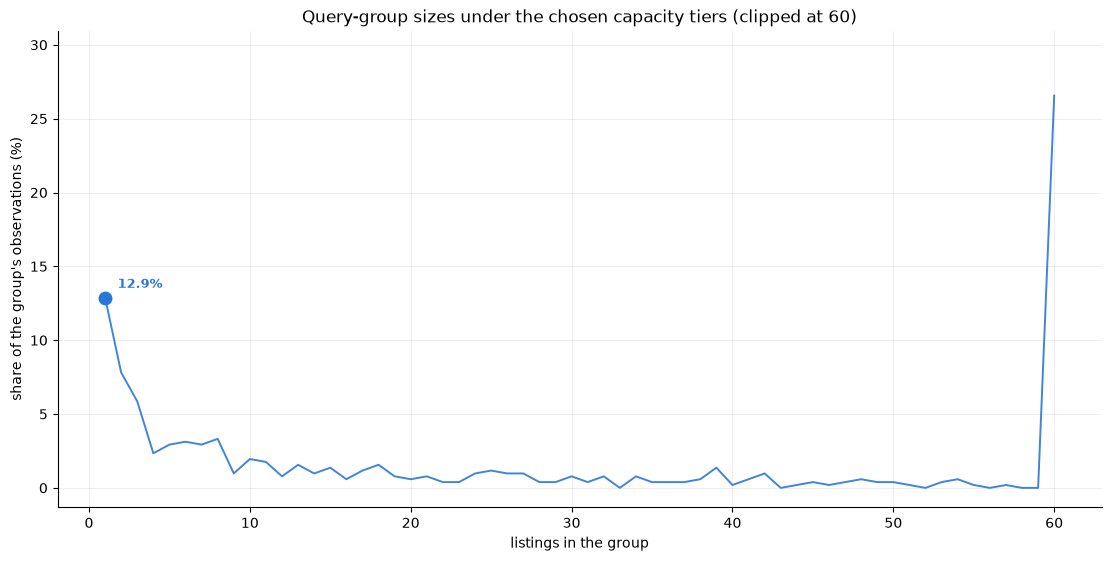

In [17]:
sizes = (
    ranked.assign(cap=pd.cut(ranked["accommodates"], [0, 2, 4, 7, 100]))
    .groupby(["city", "neighbourhood_cleansed", "room_grp", "cap"], observed=True)
    .size()
)

fig, _ = eda.plot_discrete_distribution(
    sizes.clip(upper=60),
    levels=range(1, 61),
    highlight=(1,),
    title="Query-group sizes under the chosen capacity tiers (clipped at 60)",
    xlabel="listings in the group",
)

The two candidate four-tier cuts are indistinguishable on every count, so the choice came down to
semantics: `8+` starts the top tier at a real party size, so we went with that.

The leftover singletons are **not** a rare-neighbourhood problem: most of the listings whose
group falls below five rows sit in *large* neighbourhoods, and are rare only in the crossing
with room type and capacity. Modelling phase handles them with a minimum group size and a fallback
that drops the neighbourhood dimension.